# CASO: Detección de fraudes - Creación de variables con LLM

En la siguiente actividad tendrá que explorar la data proporcionada, crear las variables propuestas usando LLM y proponer otras variables adicionales.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
root_path = os.getcwd()
print(f"Current working directory: {root_path}")

Current working directory: c:\Users\Nitvn\Documentos\Dev\ai-applications-in-industry\scoring-fraud-detection


# SECCIÓN 1: Importar datos y exploración inicial

## Ejercicio 1
1a. Carge los datos con el nombre de df (Archivo: df_caso_fraude.csv)

1b. ¿Qué observa sobre las variables del dataset?

In [3]:
# COMPLETAR 1a
df = pd.read_csv(root_path + "/data/df_caso_fraude.csv", encoding="utf-8")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39967 entries, 0 to 39966
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp              39967 non-null  str    
 1   time_since_login_min   39967 non-null  float64
 2   transaction_amount     39967 non-null  float64
 3   transaction_type       37514 non-null  str    
 4   is_first_transaction   39967 non-null  bool   
 5   user_tenure_months     39967 non-null  float64
 6   predicted_fraud_proba  39967 non-null  float64
 7   predicted_fraud        39967 non-null  int64  
 8   is_fraud               39967 non-null  int64  
dtypes: bool(1), float64(4), int64(2), str(2)
memory usage: 2.5 MB


COMPLETAR

1b.

## Ejercicio 2
Evalue la distribución de la variable target (is_fraud) ¿Esta balanceado o desbalanceado?

Pista: Puedes usar .value_counts()  o incluso hacer un grafico para ver la distribución

   labels  values
0       0   20008
1       1   19959


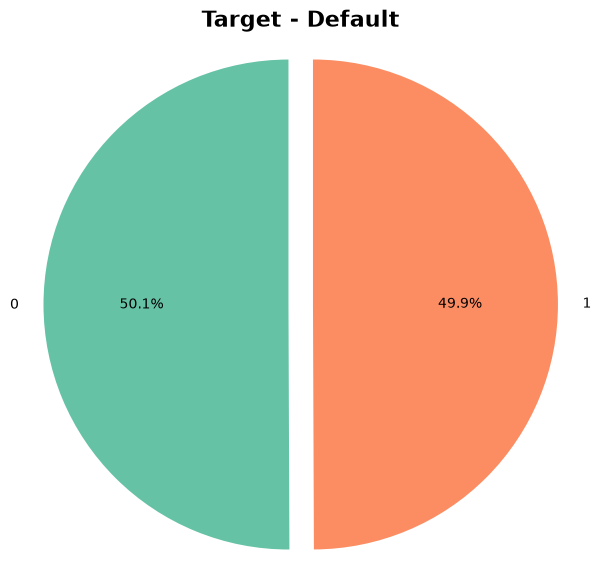

In [6]:
# COMPLETAR
# La data esta balanceada
temp = df["is_fraud"].value_counts()
data = pd.DataFrame({'labels': temp.index, 'values': temp.values})
print(data)
colors = sns.color_palette("Set2", n_colors=len(data))

plt.figure(figsize=(7, 7))
plt.pie(data['values'], labels=data['labels'], autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.1, 0))

plt.title('Target - Default', fontsize=16, weight='bold')

plt.axis('equal')
plt.show()

Distribución de transaction_type

In [7]:
# Se observa el porcentaje que representa cada tipo de transacción
df["transaction_type"].value_counts(normalize=True)

transaction_type
PAYMENT     0.401477
CASH-IN     0.267100
CASH-OUT    0.264675
TRANSFER    0.066748
Name: proportion, dtype: float64

     labels  values
0   PAYMENT   15061
1   CASH-IN   10020
2  CASH-OUT    9929
3  TRANSFER    2504


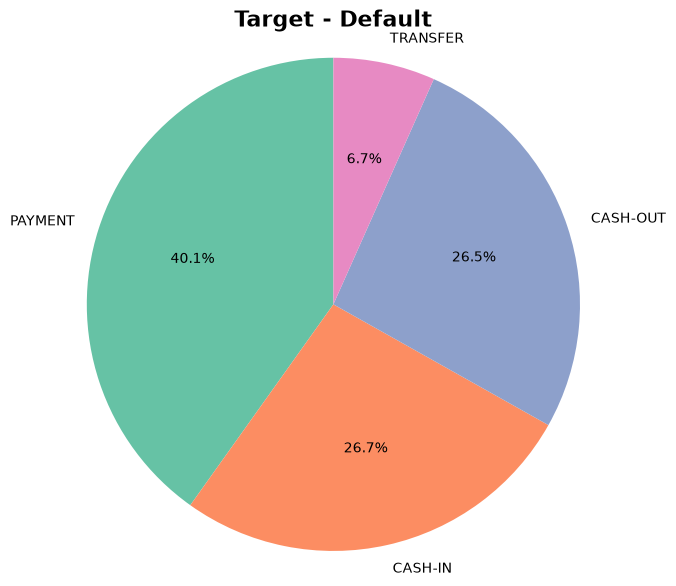

In [10]:
temp = df["transaction_type"].value_counts()
data = pd.DataFrame({'labels': temp.index, 'values': temp.values})
print(data)
colors = sns.color_palette("Set2", n_colors=len(data))

plt.figure(figsize=(7, 7))
plt.pie(data['values'], labels=data['labels'], autopct='%1.1f%%', startangle=90, colors=colors,)

plt.title('Target - Default', fontsize=16, weight='bold')

plt.axis('equal')
plt.show()

Tasa de fraude por transaction_type.

In [8]:
fraud_rate_by_type = (
    df.groupby("transaction_type")["is_fraud"]
      .mean()
      .sort_values(ascending=False)
)
fraud_rate_by_type

transaction_type
TRANSFER    0.501997
CASH-IN     0.501896
CASH-OUT    0.501763
PAYMENT     0.496913
Name: is_fraud, dtype: float64

## Ejercicio 3
Según el resultado anterior, ¿qué tipo de transacción parece más riesgosa?

El tipo de transaccion PAYMENT es el mas riesgoso por su cantidad de transacciones y media de clasificados como fraude

COMPLETAR




# SECCIÓN 2: Modelo base sin GenAI

Se construye un modelo base (LogisticRegression o RandomForest) que use como features:

*   time_since_login_min
*   transaction_amount
*   is_first_transaction
*   user_tenure_months
*   transaction_type (one-hot)

Se separo train/test (30% test, estratificado).

Se calcula AUC y recall para is_fraud = 1.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score

features_base = [
    "time_since_login_min",
    "transaction_amount",
    "is_first_transaction",
    "user_tenure_months",
    "transaction_type"
]

X = df[features_base]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

numeric_features = [
    "time_since_login_min",
    "transaction_amount",
    "is_first_transaction",
    "user_tenure_months"
]
cat_features = ["transaction_type"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

clf_base = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

clf_base.fit(X_train, y_train)

y_proba_base = clf_base.predict_proba(X_test)[:, 1]
y_pred_base = (y_proba_base >= 0.5).astype(int)

print("AUC base:", roc_auc_score(y_test, y_proba_base))
print("Recall base:", recall_score(y_test, y_pred_base))


AUC base: 0.7228964564700504
Recall base: 0.572311289245157


## Ejercicio 4
En base al resultado anterior de AUC y Recall. ¿Qué tan buenos son los resultados para este caso de detección de fraudes?

COMPLETAR

El Recall (0.57) es crítico: En un escenario balanceado, si el modelo simplemente predijera que todo es fraude, tendría un Recall de 1.0 (y una precisión horrible). Que tu Recall sea de solo 0.57 —estando los datos nivelados— significa que el modelo está confundiendo casi la mitad de los fraudes con transacciones legítimas. Básicamente, su capacidad de acierto está apenas por encima de tirar una moneda al aire.

El AUC (0.72) es muy bajo para datos balanceados: Cuando un set de datos está perfectamente balanceado (50% fraude, 50% no fraude), un modelo aleatorio (que adivina al azar) obtiene un AUC de 0.50. Que tu modelo solo llegue a 0.72 significa que, a pesar de tener una cantidad enorme de ejemplos de fraude para aprender, sus reglas de decisión siguen siendo débiles y no logra separar bien las dos clases.

Los resultados no son buenos. El modelo actual es demasiado permisivo. Se necesita ajustar el umbral de decisión para priorizar el Recall, balancear mejor los datos (usando técnicas como SMOTE o submuestreo) o probar con algoritmos más robustos (como XGBoost o LightGBM) para elevar urgentemente la tasa de detección.

# SECCIÓN 3: Diseñar y generación de variables con LLM

In [12]:
df.columns

Index(['timestamp', 'time_since_login_min', 'transaction_amount',
       'transaction_type', 'is_first_transaction', 'user_tenure_months',
       'predicted_fraud_proba', 'predicted_fraud', 'is_fraud'],
      dtype='str')

## Ejercicio 5

Define, en tus palabras, qué significa cada una de estas variables propuestas:

RISK_SEGMENT

ALERT_LEVEL

RECOMMENDED_ACTION



COMPLETAR

RISK_SEGMENT: un rango que define el riezgo de una transaccion segun criterios establecidos

ALERT_LEVEL: nivel de alertas definidas segun el RISK_SEGMENT

RECOMMENDED_ACTION: acciones recomendadas segun el ALERT_LEVEL

## Ejercicio 6
¿De que forma crees que un analista humano podría usar
estas variables del dataframe para generar las variables propuestas?:

Variables del dataframe
* time_since_login_min
* transaction_amount
* transaction_type
* is_first_transaction
* user_tenure_months
* predicted_fraud_proba

COMPLETAR

Si el modelo dice que hay 75% de probabilidad de fraude (predicted_fraud_proba), el usuario es nuevo (user_tenure_months = 0) y el monto es alto...

RISK_SEGMENT = "Fraude_Nuevo_Usuario"

ALERT_LEVEL = 3

RECOMMENDED_ACTION = BLOCK

In [25]:
# Importando librerias
import os
import json
import getpass
import textwrap

## Ejercicio 7
Agrege el codigo necesario para ingresar la API KEY DE GOOGLE para usar un modelo de gemini

Debe de ingresarse con el nombre de GOOGLE_API_KEY

In [13]:
# COMPLETAR
from dotenv import load_dotenv

# Load the .env file
load_dotenv()

google_api_key = os.getenv("GOOGLE_API_KEY")

Diseñamos un prompt instructivo para que el LLM reciba el perfil de una transacción y devuelva:

RISK_SEGMENT (texto corto)

ALERT_LEVEL (1, 2, 3)

RECOMMENDED_ACTION (BLOCK, REVIEW, ALLOW)


Se implemento el prompt en código usando PromptTemplate de LangChain donde se indica que el resultado a devolver es un diccionario para cada registro

In [16]:
import google.generativeai as genai

c:\Users\Nitvn\Documentos\Dev\ai-applications-in-industry\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Nitvn\AppData\Local\Temp\ipykernel_5212\613638648.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [21]:
#genai.configure(api_key=os.environ["GOOGLE_API_KEY"]) # Using configure

model = genai.GenerativeModel("gemini-2.5-flash")

import textwrap

def build_batch_prompt(df_batch):
    lineas = []
    for i, row in df_batch.reset_index(drop=True).iterrows():
        idx = i + 1
        lineas.append(
            f'{idx}) monto={row["transaction_amount"]}, '
            f'tipo="{row["transaction_type"]}", '
            f'min_desde_login={row["time_since_login_min"]}, '
            f'primera_tx={row["is_first_transaction"]}, '
            f'antiguedad_meses={row["user_tenure_months"]}, '
            f'proba_modelo={row["predicted_fraud_proba"]}'
        )
    clientes_txt = "\n".join(lineas)

    prompt = f"""
Eres un analista de fraude en un banco digital.

Para cada transacción numerada debes:
- Definir RISK_SEGMENT (texto corto),
- Asignar ALERT_LEVEL (1=bajo, 2=medio, 3=alto),
- Recomendar RECOMMENDED_ACTION (BLOCK, REVIEW, ALLOW).

Transacciones:
{clientes_txt}

Responde EXCLUSIVAMENTE en formato JSON:

{{
  "1": {{
"RISK_SEGMENT": "...", "ALERT_LEVEL": <1-3>, "RECOMMENDED_ACTION": "<BLOCK|REVIEW|ALLOW>"}},
  "2": {{...}},
  ...
}}
"""
    return textwrap.dedent(prompt).strip()


Aplicando la función de llamada al LLM sobre una muestra de 100 transacciones para no consumir demasiados tokens.

Nota: Si toma demasiado tiempo la ejecución puede modificar la siguiente celda para solo una muestra de 10

In [23]:
%%time

import json

# Tomamos hasta 100 filas
df_batch = df.sample(100, random_state=42).copy()

prompt = build_batch_prompt(df_batch)

resp = model.generate_content(prompt)
text = resp.text

# Extraer JSON
start = text.find("{")
end = text.rfind("}")
json_str = text[start:end+1]
data = json.loads(json_str)  # dict: "1" -> dict con scores

# Mapear resultados a un DataFrame
rows = []
df_batch_reset = df_batch.reset_index(drop=True)

for i, row in df_batch_reset.iterrows():
    idx = str(i + 1)
    s = data.get(idx, {})
    rows.append({
        "RISK_SEGMENT":        s.get("RISK_SEGMENT", "UNKNOWN"),
        "ALERT_LEVEL":         int(s.get("ALERT_LEVEL", 2)),
        "RECOMMENDED_ACTION":  s.get("RECOMMENDED_ACTION", "REVIEW"),
    })

features_llm = pd.DataFrame(rows)
df_batch_llm = pd.concat([df_batch_reset, features_llm], axis=1)
df_batch_llm.head()


CPU times: total: 93.8 ms
Wall time: 2min 22s


,timestamp,time_since_login_min,transaction_amount,transaction_type,is_first_transaction,user_tenure_months,predicted_fraud_proba,predicted_fraud,is_fraud,RISK_SEGMENT,ALERT_LEVEL,RECOMMENDED_ACTION
0,2019-05-01 20:46:02.784,1.799646,3404.4,CASH-OUT,True,5.913862,0.41,0,1,Speed Anomaly & High Risk Type (Model Moderate),2,REVIEW
1,2018-11-05 10:01:10.272,1.924569,4444.2,CASH-OUT,False,1.464055,0.97,1,1,Model Critical Risk,3,BLOCK
2,2019-02-12 11:36:00.144,1.685429,1366.4,PAYMENT,False,10.014541,0.08,0,0,Low Model Prob with Behavioral Anomaly,1,ALLOW
3,2019-04-30 15:59:38.688,1.708647,2982.6,CASH-IN,False,6.395349,0.05,0,0,Low Model Prob with Behavioral Anomaly,1,ALLOW
4,2019-01-07 05:51:35.424,2.842512,1189.4,NaN,False,4.994541,0.98,1,1,Model Critical Risk,3,BLOCK


In [ ]:
df_batch_llm.head(10)

## Ejercicio 8
¿Qué mejoras planterias al prompt usado en los pasos anteriores?

COMPLETAR

por ejemplo definir los criterios de las variables:

Eres un analista experto en riesgo y fraude de un banco digital. Tu objetivo es evaluar transacciones y categorizarlas según su nivel de riesgo operativo y financiero.

Criterios de evaluación que debes seguir estrictamente:
- RISK_SEGMENT: Clasificación cualitativa (ej. "Usuario Nuevo Sospechoso", "Transacción Inusual de Alto Monto", "Comportamiento Habitual", "Posible Robo de Cuenta").
- ALERT_LEVEL:
  * 3 (Alto): Probabilidad de fraude alta (>80%), o montos muy altos en cuentas nuevas o logins sospechosos.
  * 2 (Medio): Comportamiento inusual (ej. primer login en mucho tiempo), montos medianos con sospecha moderada.
  * 1 (Bajo): Patrones normales, usuarios antiguos, baja probabilidad de fraude.
- RECOMMENDED_ACTION:
  * BLOCK: Obligatorio para ALERT_LEVEL 3. Corta el flujo financiero de inmediato.
  * REVIEW: Para ALERT_LEVEL 2. Requiere que un humano valide la identidad del cliente.
  * ALLOW: Para ALERT_LEVEL 1. La transacción procesa normalmente.

Analiza las siguientes transacciones:
{clientes_txt}

Responde EXCLUSIVAMENTE con el objeto JSON solicitado. No incluyas introducciones, explicaciones, ni bloques de código de markdown (```json). Tu respuesta debe comenzar con {{ y terminar con }}.

Formato requerido:
{{    
  "1": {{
    "RISK_SEGMENT": "...",
    "ALERT_LEVEL": <1-3>,
    "RECOMMENDED_ACTION": "<BLOCK|REVIEW|ALLOW>"
  }},
  "2": {{...}}
}}

## Ejercicio 9
Propón al menos 3 nuevas variables que podrías generar con un LLM.



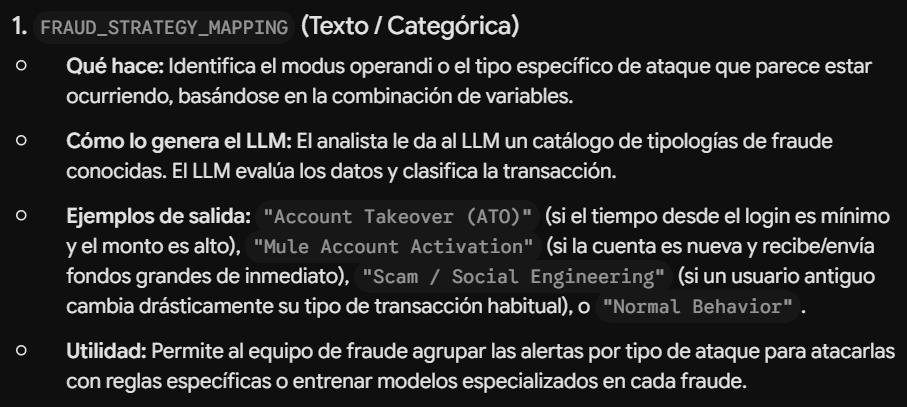

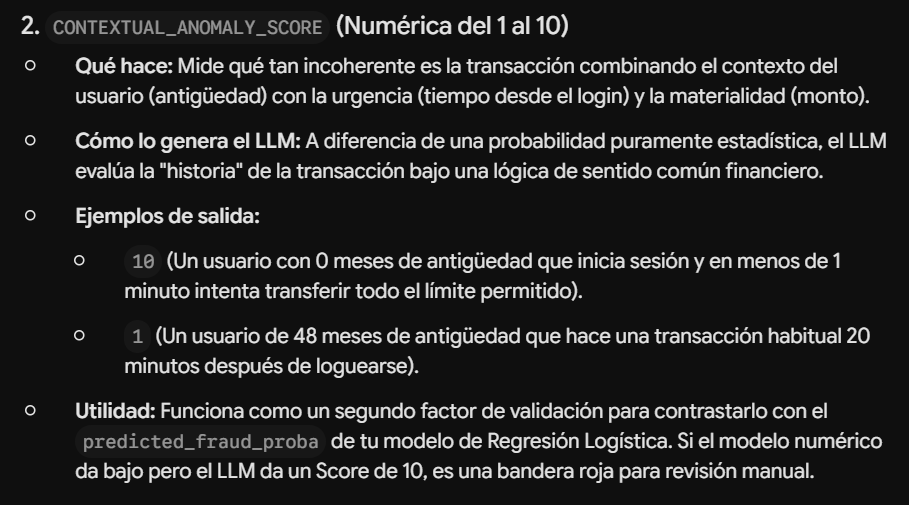

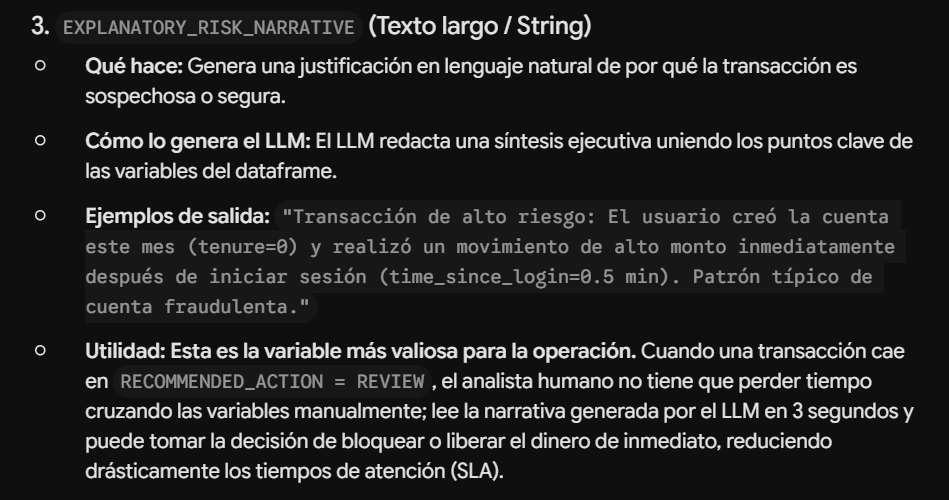

COMPLETAR

## Ejercicio 10
Escribe el prompt que usarías (qué variables de entrada le darías, qué escala de salida).

COMPLETAR

```
Eres un analista experto en riesgo y fraude de un banco digital. Tu objetivo es evaluar transacciones y categorizarlas según su nivel de riesgo operativo y financiero.

Criterios de evaluación que debes seguir estrictamente:
- RISK_SEGMENT: Clasificación cualitativa (ej. "Usuario Nuevo Sospechoso", "Transacción Inusual de Alto Monto", "Comportamiento Habitual", "Posible Robo de Cuenta").
- ALERT_LEVEL:
  * 3 (Alto): Probabilidad de fraude alta (>80%), o montos muy altos en cuentas nuevas o logins sospechosos.
  * 2 (Medio): Comportamiento inusual (ej. primer login en mucho tiempo), montos medianos con sospecha moderada.
  * 1 (Bajo): Patrones normales, usuarios antiguos, baja probabilidad de fraude.
- RECOMMENDED_ACTION:
  * BLOCK: Obligatorio para ALERT_LEVEL 3. Corta el flujo financiero de inmediato.
  * REVIEW: Para ALERT_LEVEL 2. Requiere que un humano valide la identidad del cliente.
  * ALLOW: Para ALERT_LEVEL 1. La transacción procesa normalmente.
- FRAUD_STRATEGY_MAPPING: Identifica el modus operandi o tipo específico de ataque basándote en la combinación de variables. Clasifica según las siguientes tipologías conocidas: "Account Takeover (ATO)", "Mule Account Activation", "Scam / Social Engineering" o "Normal Behavior".
- CONTEXTUAL_ANOMALY_SCORE: Puntuación numérica del 1 al 10 que mide la incoherencia de la transacción bajo una lógica de sentido común financiero (ej. 10 para una cuenta recién creada que intenta vaciar fondos en menos de un minuto; 1 para transacciones habituales de clientes antiguos).
- EXPLANATORY_RISK_NARRATIVE: Redacta una síntesis ejecutiva y breve en lenguaje natural que justifique el nivel de riesgo uniendo los puntos clave de las variables analizadas. Servirá para que un analista humano tome decisiones en segundos.

Analiza las siguientes transacciones:
{clientes_txt}

Responde EXCLUSIVAMENTE con el objeto JSON solicitado. No incluyas introducciones, explicaciones, ni bloques de código de markdown (```json). Tu respuesta debe comenzar con { y terminar con }.

Formato requerido:
{    
  "1": {
    "RISK_SEGMENT": "...",
    "ALERT_LEVEL": <1-3>,
    "RECOMMENDED_ACTION": "<BLOCK|REVIEW|ALLOW>",
    "FRAUD_STRATEGY_MAPPING": "...",
    "CONTEXTUAL_ANOMALY_SCORE": <1-10>,
    "EXPLANATORY_RISK_NARRATIVE": "..."
  },
  "2": {
    "RISK_SEGMENT": "...",
    "ALERT_LEVEL": <1-3>,
    "RECOMMENDED_ACTION": "<BLOCK|REVIEW|ALLOW>",
    "FRAUD_STRATEGY_MAPPING": "...",
    "CONTEXTUAL_ANOMALY_SCORE": <1-10>,
    "EXPLANATORY_RISK_NARRATIVE": "..."
  }
}
```